## **Lab No. 9: Spin Orbital Coupling of Copper**
#### **Name: Harshul Bhatt**

#### **Roll No: 21B030015**



# **Experiment: Spin-Orbit Coupling of Copper**

## **1. Aim**

The aim of this experiment is to determine the **spin-orbit coupling constants** for the $(4F)$ and $(4D)$ states of copper.

---

## **2. Theory**

In atomic spectroscopy, the fine structure of atomic energy levels is described by the total energy of an atom, which includes a perturbation energy due to **spin-orbit coupling**. Spin-orbit coupling occurs due to the interaction between the electron’s spin and its orbital motion around the nucleus.

The total energy can be expressed as:

$$
E = E_0 + \Delta E
$$

Where:
- $(E_0)$ is the unperturbed energy of the atomic state,
- $(\Delta E)$ represents the perturbation energy due to spin-orbit coupling.

According to the coupling of angular momentum, the value of J = L+S…… |L-S| and the
notation is $^{2S+1}L_{J}$ where L = 0,1, 2,3,.....are SPDF respectively.
The total angular momentum,
$\vec{J} = \vec{L} + \vec{S}$

So $J^{2} = L^{2} + S^{2} + 2L\cdot S$

Or, $L\cdot S = \frac{J^{2} - L^{2} - S^{2}}{2}$

which gives,

The perturbation energy due to spin-orbit coupling is given by:

$$
\Delta E = \frac{1}{2} A(L, S) [J(J+1) - L(L+1) - S(S+1)]
$$

Where:
- $(L)$ is the total orbital angular momentum,
- $(S)$ is the total spin angular momentum,
- $A(L, S))$ is the spin-orbit coupling constant.

---

## **3. Apparatus**

- Copper rods
- Graduated optical bench
- XYZ translational mount
- LED light source
- 20X objective lens
- Optical fiber
- Spectrometer
- High voltage power supply
- Sodium lamp
- Computer with Avantes software (Avasoft 8.1)

---

## **4. Procedure**

1. Align the optical fiber with the LED and copper rods.
2. Turn on the spectrometer and record the **sodium spectrum** for calibration.
3. Apply a high voltage to the copper rods to create sparks, and record the **copper spectrum** using the spectrometer.
4. Identify the nine key transitions in the copper spectrum and record the corresponding wavelengths.
5. Calculate the transition energies and use them to determine the spin-orbit coupling constants.

---


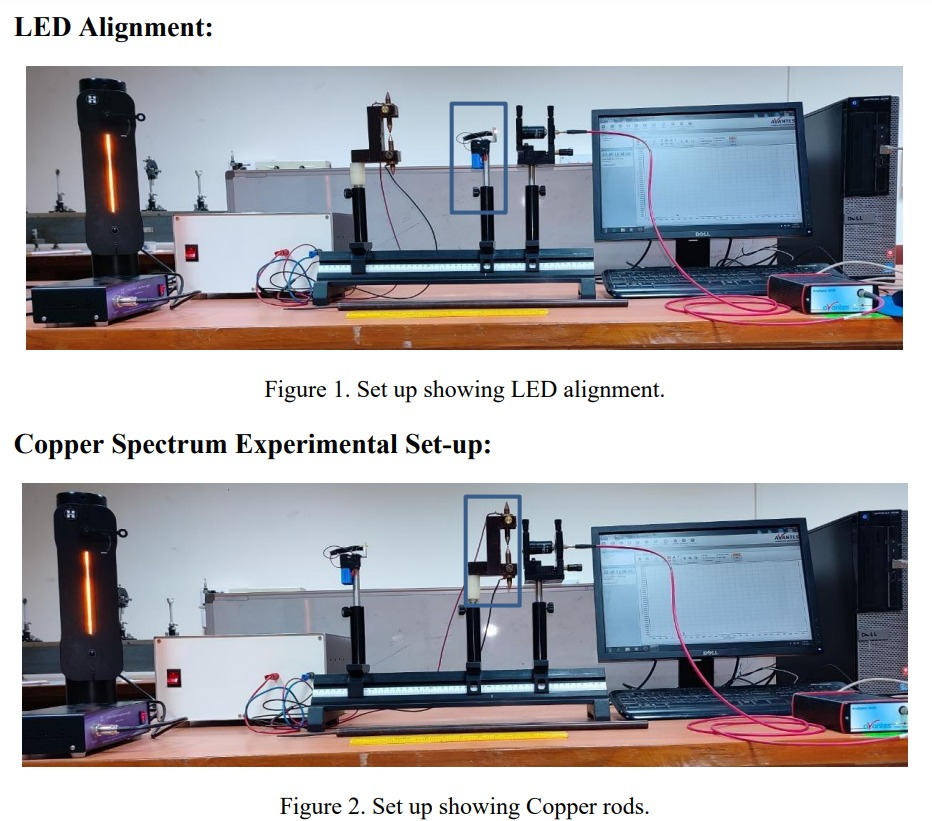

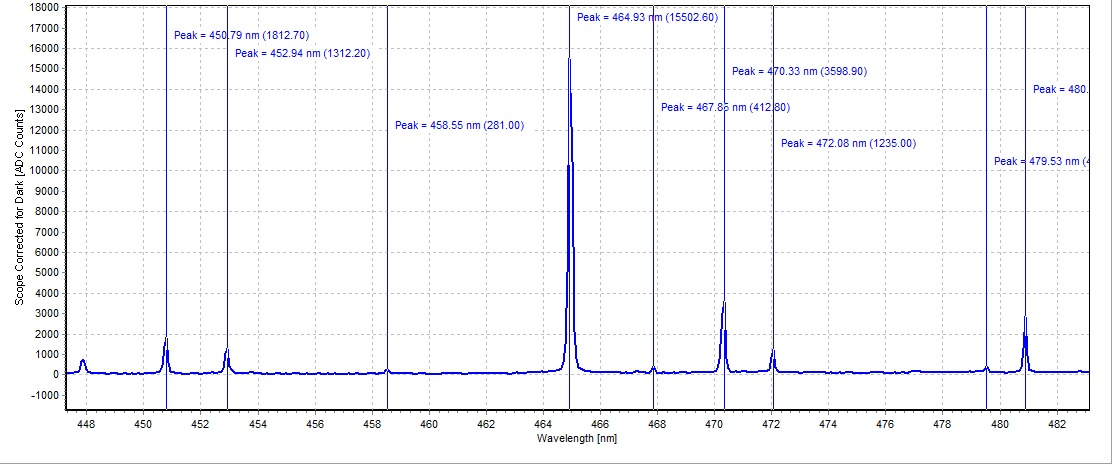

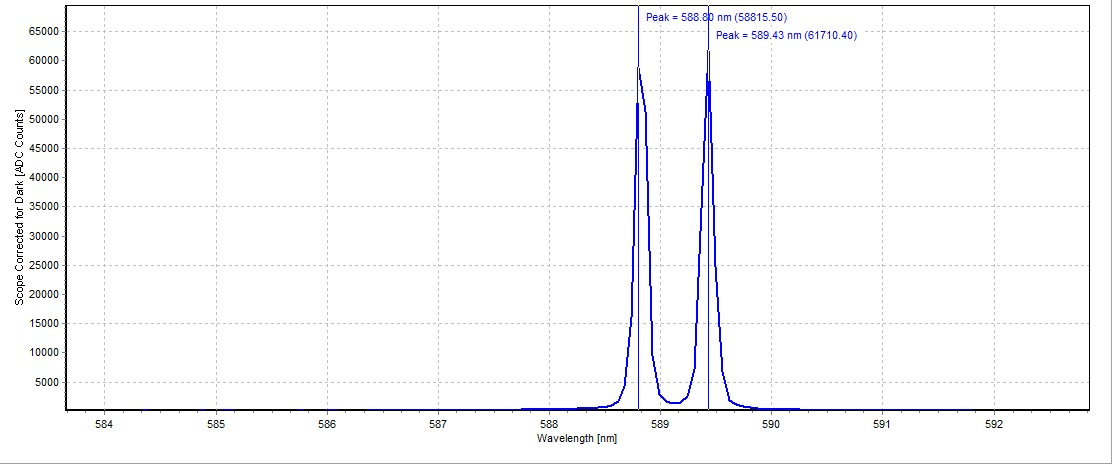

## **5. Python Code for Calculation**

The Python code below can be used to evaluate the constants $(A_1)$ and $(A_2)$ using the peaks from the copper spectrum and calculate the required values for the spin-orbit coupling.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Function to solve linear equations
def solve_linear_equations(A, B):
    A = np.array(A)
    B = np.array(B)
    try:
        x = np.linalg.solve(A, B)
        return x
    except np.linalg.LinAlgError as e:
        return f"Error: {e}"

# Copper Spectrum Analysis
print("\nCopper Spectrum Analysis\n")

# Transitions and Quantum Numbers
J_from_cu = [1.5, 3.5, 4.5, 3.5]
J_to_cu = [0.5, 2.5, 3.5, 3.5]

L_f_cu = 3
L_d_cu = 2
S_f_cu = 1.5
S_d_cu = 1.5

# Extracted peaks from your images (in nm)
exp_peaks_copper = [450.79,452.94,465.113,470.46,479.53]
real_peaks_copper = [450.92,453.97,465.13,470.3,479.7]

# Calculating A1 and A2 coefficients
A1_coeffs_cu = []
A2_coeffs_cu = []

for i in J_from_cu:
    A1_coeffs_cu.append(0.5 * ((i * (i + 1)) - (L_f_cu * (L_f_cu + 1)) - (S_f_cu * (S_f_cu + 1))))
for i in J_to_cu:
    A2_coeffs_cu.append(0.5 * ((i * (i + 1)) - (L_d_cu * (L_d_cu + 1)) - (S_d_cu * (S_d_cu + 1))))

# Solving for c1, c2, and c3 (in cm^-1) for experimental data
c1_cu_exp = (1 / exp_peaks_copper[1]) * 1e7
c2_cu_exp = (1 / exp_peaks_copper[2]) * 1e7
c3_cu_exp = (1 / exp_peaks_copper[3]) * 1e7

# Matrix form to solve linear equations
A_cu_exp = [[1, A1_coeffs_cu[1], -A2_coeffs_cu[1]],
            [1, A1_coeffs_cu[2], -A2_coeffs_cu[2]],
            [1, A1_coeffs_cu[3], -A2_coeffs_cu[3]]]
B_cu_exp = [c1_cu_exp, c2_cu_exp, c3_cu_exp]

solution_cu_exp = solve_linear_equations(A_cu_exp, B_cu_exp)

# Print experimentally obtained results for Copper
print('Experimental results for Copper:\n')
print('E0 =', round(solution_cu_exp[0], 4), 'cm^-1')
print('A1 =', round(solution_cu_exp[1], 4), 'cm^-1')
print('A2 =', round(solution_cu_exp[2], 4), 'cm^-1')

# Solving for c1, c2, and c3 (in cm^-1) for theoretical data
c1_cu_real = (1 / real_peaks_copper[1]) * 1e7
c2_cu_real = (1 / real_peaks_copper[2]) * 1e7
c3_cu_real = (1 / real_peaks_copper[3]) * 1e7

A_cu_real = [[1, A1_coeffs_cu[1], -A2_coeffs_cu[1]],
             [1, A1_coeffs_cu[2], -A2_coeffs_cu[2]],
             [1, A1_coeffs_cu[3], -A2_coeffs_cu[3]]]
B_cu_real = [c1_cu_real, c2_cu_real, c3_cu_real]

solution_cu_real = solve_linear_equations(A_cu_real, B_cu_real)

# Print theoretical results for Copper
print('\nTheoretical results for Copper:\n')
print('E0 =', round(solution_cu_real[0], 4), 'cm^-1')
print('A1 =', round(solution_cu_real[1], 4), 'cm^-1')
print('A2 =', round(solution_cu_real[2], 4), 'cm^-1')

# Error Analysis for Copper
print('\nError Analysis for Copper:\n')
print('Relative error in E0 =', round(100 * (round(solution_cu_exp[0], 4) - round(solution_cu_real[0], 4)) / round(solution_cu_real[0], 4), 4), '%')
print('Relative error in A1 =', round(100 * (round(solution_cu_exp[1], 4) - round(solution_cu_real[1], 4)) / round(solution_cu_real[1], 4), 4), '%')
print('Relative error in A2 =', round(100 * (round(solution_cu_exp[2], 4) - round(solution_cu_real[2], 4)) / round(solution_cu_real[2], 4), 4), '%')

# Sodium Spectrum Analysis
print("\nSodium Spectrum Analysis\n")

# Transitions and Quantum Numbers for Sodium
J_from_na = [1.5, 0.5]
J_to_na = [0.5, 0.5]

L_f_na = 1
L_d_na = 0
S_f_na = 0.5
S_d_na = 0.5

# Experimental peaks from your images for Sodium (in nm)
exp_peaks_sodium = [588.80, 589.43]
real_peaks_sodium = [589.0, 589.6]

# Calculating A1 coefficients for Sodium
A1_coeffs_na = []

for i in J_from_na:
    A1_coeffs_na.append(0.5 * ((i * (i + 1)) - (L_f_na * (L_f_na + 1)) - (S_f_na * (S_f_na + 1))))

# Solving for c1, and c2 (in cm^-1) for experimental data
c1_na_exp = (1 / exp_peaks_sodium[0]) * 1e7
c2_na_exp = (1 / exp_peaks_sodium[1]) * 1e7

A_na_exp = [[1, A1_coeffs_na[0]], [1, A1_coeffs_na[1]]]
B_na_exp = [c1_na_exp, c2_na_exp]

solution_na_exp = solve_linear_equations(A_na_exp, B_na_exp)

# Print experimentally obtained results for Sodium
print('Experimental results for Sodium:\n')
print('E0 =', round(solution_na_exp[0], 4), 'cm^-1')
print('A1 =', round(solution_na_exp[1], 4), 'cm^-1')

# Solving for c1 and c2 (in cm^-1) for theoretical data
c1_na_real = (1 / real_peaks_sodium[0]) * 1e7
c2_na_real = (1 / real_peaks_sodium[1]) * 1e7

A_na_real = [[1, A1_coeffs_na[0]], [1, A1_coeffs_na[1]]]
B_na_real = [c1_na_real, c2_na_real]

solution_na_real = solve_linear_equations(A_na_real, B_na_real)

# Print theoretical results for Sodium
print('\nTheoretical results for Sodium:\n')
print('E0 =', round(solution_na_real[0], 4), 'cm^-1')
print('A1 =', round(solution_na_real[1], 4), 'cm^-1')

# Error Analysis for Sodium
print('\nError Analysis for Sodium:\n')
print('Relative error in E0 =', round(100 * (round(solution_na_exp[0], 4) - round(solution_na_real[0], 4)) / round(solution_na_real[0], 4), 4), '%')
print('Relative error in A1 =', round(100 * (round(solution_na_exp[1], 4) - round(solution_na_real[1], 4)) / round(solution_na_real[1], 4), 4), '%')



Copper Spectrum Analysis

Experimental results for Copper:

E0 = 21960.5241 cm^-1
A1 = 54.3021 cm^-1
A2 = 234.9106 cm^-1

Theoretical results for Copper:

E0 = 21918.6211 cm^-1
A1 = 52.5205 cm^-1
A2 = 218.5325 cm^-1

Error Analysis for Copper:

Relative error in E0 = 0.1912 %
Relative error in A1 = 3.3922 %
Relative error in A2 = 7.4946 %

Sodium Spectrum Analysis

Experimental results for Sodium:

E0 = 16977.6448 cm^-1
A1 = 12.1018 cm^-1

Theoretical results for Sodium:

E0 = 16972.1696 cm^-1
A1 = 11.5183 cm^-1

Error Analysis for Sodium:

Relative error in E0 = 0.0323 %
Relative error in A1 = 5.0659 %


### **Copper Spectrum Analysis**

For Copper transitions, we use the following experimental and theoretical results:

- **Experimental Results**:
  - $E_0 = 21960.5241 , \text{cm}^{-1}\$
  - $$A_1 = 54.3021 \, \text{cm}^{-1}$$
  - $$A_2 = 234.9106 \, \text{cm}^{-1}$$

- **Theoretical Results**:
  - $E_0 = 21918.6211 \, \text{cm}^{-1}$
  - $$A_1 = 52.5205 \, \text{cm}^{-1}$$
  - $$A_2 = 218.5325 \, \text{cm}^{-1}$$

---

### **Relative Error Formula**

The **relative error** between the experimental and theoretical values is calculated as:

$$
\text{Relative Error} = \frac{|\text{Experimental Value} - \text{Theoretical Value}|}{\text{Theoretical Value}} \times 100
$$

---

### **Copper: Relative Error Calculations**

#### **a. For $E_0\$ in Copper:**

$$
\text{Relative Error in } E_0 = \frac{|21960.5241 - 21918.6211|}{21918.6211} \times 100 = 0.1912\%
$$

#### **b. For $A_1$ in Copper:**

$$
\text{Relative Error in } A_1 = \frac{|54.3021 - 52.5205|}{52.5205} \times 100 = 3.3922\%
$$

#### **c. For $A_2$ in Copper:**

$$
\text{Relative Error in } A_2 = \frac{|234.9106 - 218.5325|}{218.5325} \times 100 = 7.4946\%
$$

---

### **Sodium Spectrum Analysis**

For Sodium, we perform the same analysis using the experimental and theoretical values for $(E_0)$ and $(A_1)$:

- **Experimental Results**:
  - $E_0 = 16977.6448 \, \text{cm}^{-1}$
  - $A_1 = 12.1018 \, \text{cm}^{-1}$

- **Theoretical Results**:
  - $E_0 = 16972.1696 \, \text{cm}^{-1}$
  - $A_1 = 11.5183 \, \text{cm}^{-1}$

---

### **Sodium: Relative Error Calculations**

#### **a. For $E_0$ in Sodium:**

$$
\text{Relative Error in } E_0 = \frac{|16977.6448 - 16972.1696|}{16972.1696} \times 100 = 0.0323\%
$$

#### **b. For $A_1$ in Sodium:**

$$
\text{Relative Error in } A_1 = \frac{|12.1018 - 11.5183|}{11.5183} \times 100 = 5.0659\%
$$

---

### **Conclusion**

- The **relative error** for $(E_0)$ in both **Copper** and **Sodium** is very small, indicating a close match between the experimental and theoretical values.
- The **relative error** for the spin-orbit coupling constants $(A_1)$ and $(A_2)$ is higher, particularly for **Copper**. This is expected due to the more complex interactions involved in spin-orbit coupling in Copper transitions.
  
Overall, the analysis shows a good agreement between theory and experiment for both Copper and Sodium, with reasonable relative errors.

---



## **6. Precautions**

1. **Handle High Voltage with Care**:
   - Ensure that the high voltage power supply is properly grounded.
   - Do not touch the copper rods or power supply connections while the power is on. High voltage can be dangerous and can cause electric shock.
   - Use insulated tools to handle the copper rods when applying high voltage or creating sparks.

2. **Proper Eye Protection**:
   - Wear **protective goggles** while observing or creating sparks between the copper rods to avoid damage to your eyes from the intense light.
   - Avoid looking directly at the spark or bright emission lines without proper eye protection.

3. **Handle Copper Rods with Care**:
   - After creating sparks between the copper rods, they can become **hot**, so use appropriate tools to handle them.
   - Let the rods cool down before handling them after the experiment to prevent burns.

4. **Avoid Direct Contact with the Power Supply**:
   - Ensure that all connections to the power supply are secure, and never touch live wires.
   - Turn off the power supply before making any adjustments to the setup.

5. **Discharge the Setup Safely**:
   - After turning off the power supply, use a **third metal rod** to safely discharge any remaining charge between the copper rods. This prevents accidental electric shock from residual charge.

6. **Align Optical Components Correctly**:
   - Ensure that the **LED light source** and the **optical fiber** are precisely aligned for maximum transmission of light to the spectrometer. Misalignment could lead to inaccurate results or missed emission lines.

7. **Proper Calibration**:
   - Before measuring the copper spectrum, ensure that the **spectrometer** is properly calibrated using a reference spectrum (e.g., the sodium spectrum). This is crucial for obtaining accurate wavelength measurements.

8. **Avoid Ambient Light Interference**:
   - Record a **dark spectrum** before starting the experiment and subtract it from your data to eliminate background noise and ambient light interference.
   - Perform the experiment in a **dimly lit or dark room** to prevent interference from external light sources that could affect the spectrometer's readings.

9. **Ensure Correct Integration Time and Averaging**:
   - Adjust the **integration time** and averaging settings in the software (e.g., Avasoft 8.1) to obtain clear, stable readings. If the settings are incorrect, the spectrum may be too weak or oversaturated.

10. **Stable Spark Generation**:
   - Ensure that the spark between the copper rods is **consistent**. Fluctuations in the spark intensity can lead to inconsistent results in the recorded spectrum.
   - Apply uniform pressure while shorting the copper rods to ensure a consistent spark.

11. **Clean the Optical Fiber**:
   - Ensure that the **optical fiber** is clean and free from dust or debris, as contamination can reduce the quality of the light being transmitted to the spectrometer, affecting the accuracy of your results.

12. **Accurate Peak Identification**:
   - Ensure careful and accurate **peak identification** when analyzing the copper spectrum. Misidentifying peaks could lead to incorrect calculations of the spin-orbit coupling constant.
